In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# For reproducible results. Comment out if not required
np.random.seed(5)
torch.manual_seed(10)

<h2>Regression</h2>

<h4>Generate Data</h4>

In [3]:
N = 1000
X = np.random.multivariate_normal(mean=[1,3], cov=np.diag([1,2]), size=N)
y = X[:,0]**3 + 2*np.sin((X[:,1]))
y = y.reshape(-1,1)

<h4>Split into train, validation, and test</h4>

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.75, shuffle=True, random_state=5)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.8, shuffle=True, random_state=5)

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

<h4>Train the network</h4>

In [6]:
# 1 hidden layer with 64 neurons
# ReLU activation function

numInputs = X.shape[1]
model = nn.Sequential(
    nn.Linear(numInputs, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [7]:
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    
    model.train()
    optimizer.zero_grad() # sets gradients to zero. Prevents accumulation of gradients

    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward() # finds gradient of loss wrt parameters
    optimizer.step() # updates model parameters

    model.eval() # evaluate on validation data
    with torch.no_grad(): # gradient computation is disabled
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, y_val_t)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

model.eval() # evaluate on test data
with torch.no_grad():
    y_test_pred = model(X_test_t)

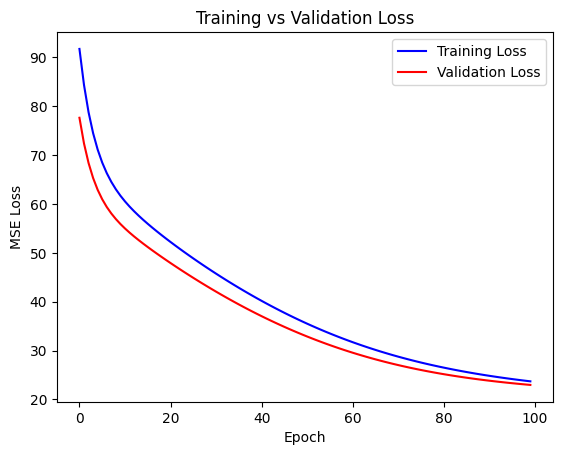

In [8]:
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

<h2>Classification</h2>

<h3>Generate data</h3>

In [9]:
N = 5000
X1 = np.random.multivariate_normal(mean=[1,1], cov=np.diag([1,2]), size=N)
X2 = np.random.multivariate_normal(mean=[5,3], cov=np.diag([1,2]), size=N)
X = np.vstack([X1, X2])

In [10]:
y = np.concat([np.repeat(0,N), np.repeat(1,N)])
y = y.reshape(-1, 1)

In [11]:
data = pd.DataFrame(np.hstack([X, y]), columns=['x1', 'x2', 'class'])

<h3>Visualization</h3>

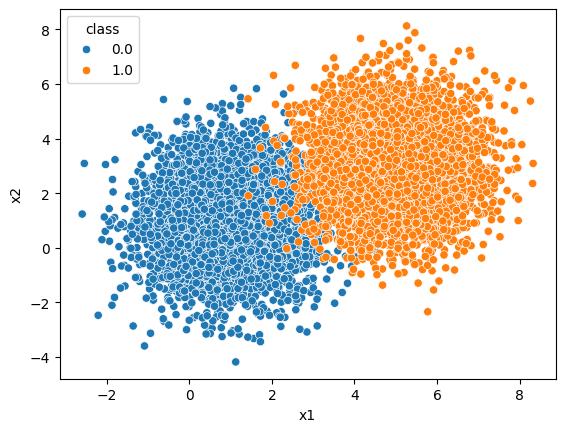

In [13]:
import seaborn as sns

sns.scatterplot(data=data, x='x1', y='x2', hue='class')
plt.show()

In [14]:
X = data[['x1','x2']].values
y = data['class'].values
y = y.reshape(-1,1)

<h4>Split into train, validation, and test</h4>

In [15]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.75, shuffle=True, random_state=5)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.8, shuffle=True, random_state=5)

In [16]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

<h4>Train the network</h4>

In [17]:
# 1 hidden layer with 64 neurons
# ReLU activation function

numInputs = X.shape[1]
model = nn.Sequential(
    nn.Linear(numInputs, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, y_val_t)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t).cpu().numpy()

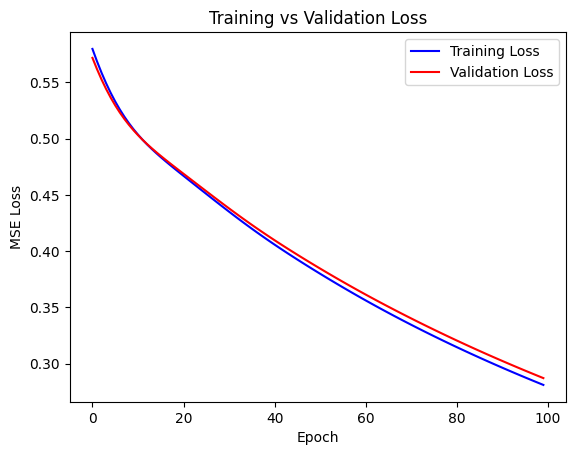

In [19]:
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [20]:
pred = np.where(y_test_pred>0.5, 1, 0)

In [21]:
print(f'Accuracy = {(y_test==pred).sum()/len(pred)*100:.2f}%')

Accuracy = 90.08%


<h3>Try changing the following:</h3>
<ol>
    <li>architecture</li>
    <li>optimizer</li>
    <li>learning rates</li>
    <li>activation function</li>
</ol>